# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')

%matplotlib inline

# Loading the Dataset

In [2]:
df = pd.read_csv(r'C:\Users\yasha\OneDrive\Desktop\inlighntech.com\My projects\Python\Zomato\Zomato data.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
df.shape

(148, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [5]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


# Data Cleaning and preparation

## Convert Ratings:

In [6]:
#checking rate column
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

In [7]:
# Splitting and converting rate column to numeric format
df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = df['rate'].astype(float)

In [8]:
# checking again after conversion
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4])

## Verify Data Types:

In [9]:
# checking the Datatypes of all columns
df.dtypes

name                            object
online_order                    object
book_table                      object
rate                           float64
votes                            int64
approx_cost(for two people)      int64
listed_in(type)                 object
dtype: object

In [10]:
# Unique Values in all columns
for col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())


Unique values in name:
['Jalsa' 'Spice Elephant' 'San Churro Cafe' 'Addhuri Udupi Bhojana'
 'Grand Village' 'Timepass Dinner'
 'Rosewood International Hotel - Bar & Restaurant' 'Onesta'
 'Penthouse Cafe' 'Smacznego' 'Village Café' 'Cafe Shuffle'
 'The Coffee Shack' 'Caf-Eleven' 'Cafe Vivacity' 'Catch-up-ino'
 "Kirthi's Biryani" 'T3H Cafe' '360 Atoms Restaurant And Cafe'
 'The Vintage Cafe' 'Woodee Pizza' 'Cafe Coffee Day' 'My Tea House'
 'Hide Out Cafe' 'CAFE NOVA' 'Coffee Tindi' 'Sea Green Cafe' 'Cuppa'
 "Srinathji's Cafe" 'Redberrys' 'Foodiction' 'Sweet Truth'
 'Ovenstory Pizza' 'Faasos' 'Behrouz Biryani' 'Fast And Fresh'
 'Szechuan Dragon' 'Empire Restaurant' 'Maruthi Davangere Benne Dosa'
 'Chaatimes' 'Havyaka Mess' "McDonald's" "Domino's Pizza" 'Hotboxit'
 'Kitchen Garden' 'Recipe' 'Beijing Bites' 'Tasty Bytes' 'Petoo'
 'Shree Cool Point' 'Corner House Ice Cream' 'Biryanis And More'
 'Roving Feast' 'FreshMenu' 'Banashankari Donne Biriyani' 'Wamama'
 'Five Star Chicken' 'XO Belgia

In [11]:
# Checking for null values
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

## Conclusion:

* Converted the Rate column into float for better analysis
* Verified the datatypes in all columns
* Checked unique values for all columns
* Checked for null values - found and confirmed no null values

# Data Analysis and Visualization

## Types of Restaurants

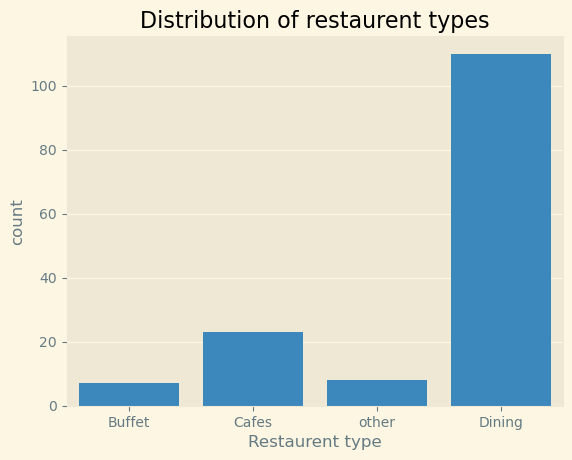

In [12]:
# count plot for restaurent types
sns.countplot(data=df, x='listed_in(type)')
plt.title('Distribution of restaurent types')
plt.xlabel('Restaurent type')
plt.show()

### Conclusion:
* Dining seems to be most common and more preferred
* Dining contributes to approx 90% of Restaurent distribution
* This strongly suggests that customers prefer sit-down dining experiences over other formats
* Dining establishments are simply far more prevalent in the region
* Cafes are next most preferred restaurent type
* Buffet and other are least preferred

## Votes by Restaurant Type

In [13]:
votes_by_type = df.groupby('listed_in(type)')['votes'].sum()
votes_by_type

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

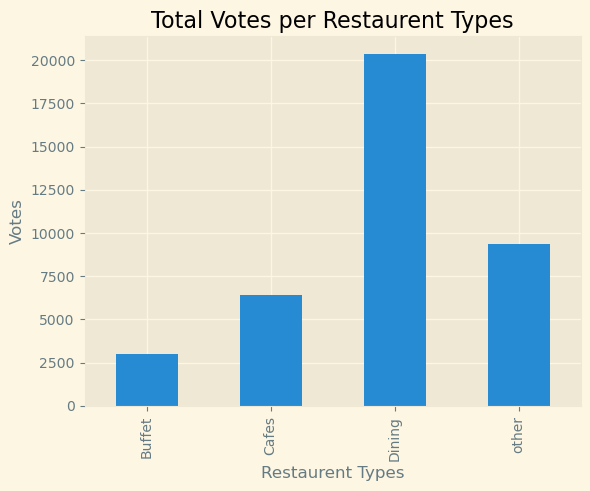

In [14]:
# Barplot of Total Votes per Restaurent Types
votes_by_type.plot(kind='bar')
plt.title('Total Votes per Restaurent Types')
plt.xlabel('Restaurent Types')
plt.ylabel('Votes')
plt.show()

## Ratings Distribution

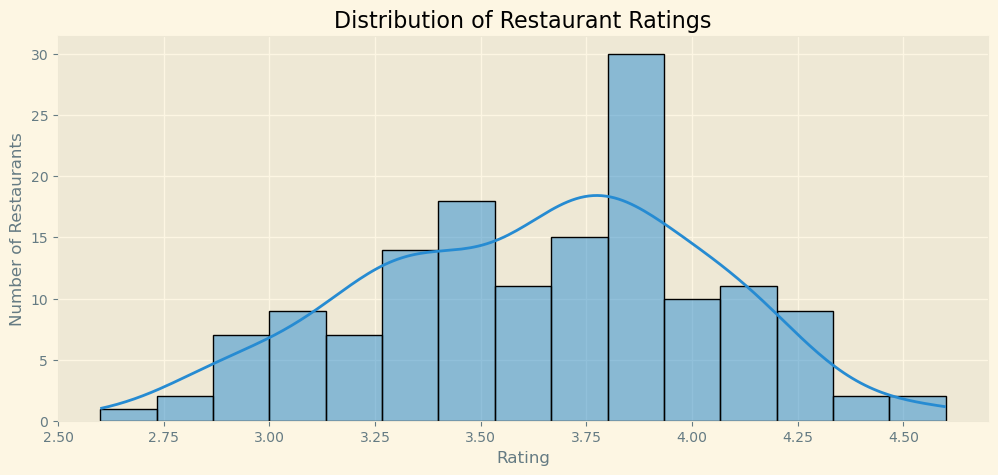

In [15]:
# histogram of the rate column
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='rate', kde=True, bins=15)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

### Conclusion:
* The rating range most restaurants fall into is (typically 3.5 to 4)
* This suggests that a rating of 3.5–4.0 is the norm
* The highest rating range for restuarants is 3.8 to 3.95
* Anything above 4.2 would be considered genuinely outstanding

# Restaurant Cost Preference for Couples

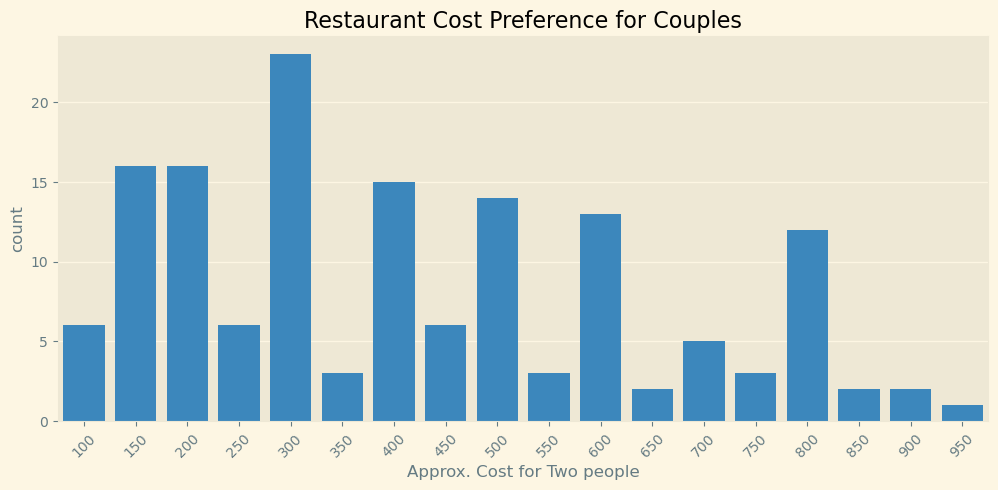

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='approx_cost(for two people)')
plt.title('Restaurant Cost Preference for Couples')
plt.xticks(rotation=45)
plt.xlabel('Approx. Cost for Two people')
plt.show()

# Online vs. Offline Ratings

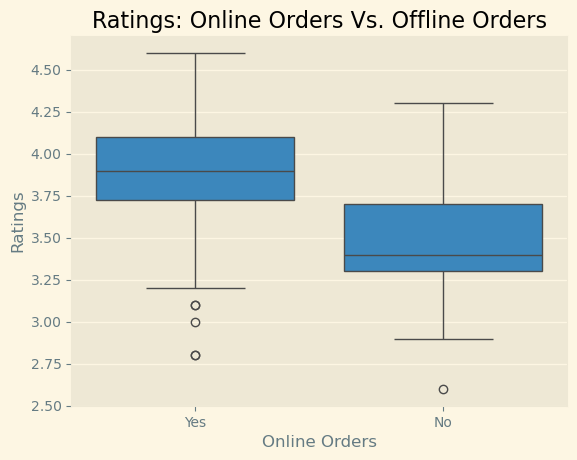

In [17]:
# Boxplot of Ratings: Online Orders Vs. Offline Orders

sns.boxplot(data=df, x='online_order', y='rate')
plt.title('Ratings: Online Orders Vs. Offline Orders')
plt.xlabel('Online Orders')
plt.ylabel('Ratings')
plt.show()

## Conclusion:
* Online orders have higher ratings than offline ones
* Restaurants that accept online orders tend to receive higher customer ratings compared to those that only serve offline
* This could suggest that the convenience of online ordering contributes to a better overall customer experience
* Restaurants with online ordering tend to be more established/quality-focused

# Online Orders by Restaurant Type

In [18]:
# Pivot table for No. of restaurant types offering online vs offline orders
pivot = pd.pivot_table(df, index='listed_in(type)', columns='online_order', values='rate', aggfunc='count')
pivot

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


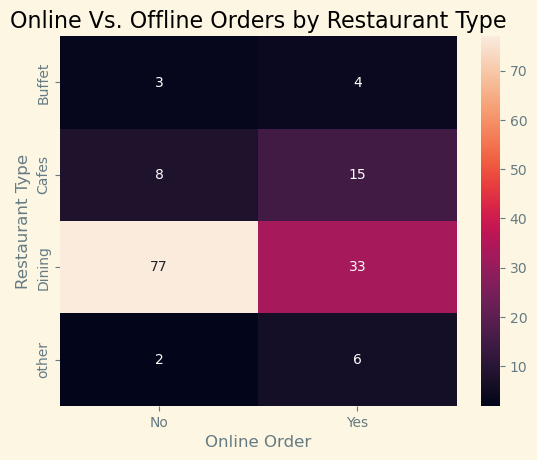

In [19]:
sns.heatmap(data= pivot, annot=True)
plt.title("Online Vs. Offline Orders by Restaurant Type")
plt.xlabel("Online Order")
plt.ylabel("Restaurant Type")
plt.show()

## Conclusion
* Cafes prefer online orders (15 vs 8 — nearly 2x more online), while Dining restaurants lean heavily toward offline orders
* Likely because cafe customers often pre-order or use delivery apps for convenience
* The brightest cell (Dining–Offline = 77) dominates the heatmap (77 vs 33 — more than 2x more offline)
* Buffet & Other categories have very small counts, but both marginally lean online
* This pattern suggests that restaurant type strongly influences ordering behavior
* Delivery/online platforms are more relevant for cafes, while dining establishments rely on walk-in customers

# Find the Insights :

## What type of restaurant do the majority of customers order from?

In [20]:
majority_type = (df[df['online_order'] == 'Yes']['listed_in(type)'].value_counts())

print(majority_type)

listed_in(type)
Dining    33
Cafes     15
other      6
Buffet     4
Name: count, dtype: int64


* The majority of customers order from Dining restaurants.
* This is evident from the highest count of dining-type restaurants and their strong customer engagement compared to other types such as cafés or delivery-only outlets

## How many votes has each type of restaurant received from customers?

In [21]:
votes_by_type = (df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False))

votes_by_type

listed_in(type)
Dining    20363
other      9367
Cafes      6434
Buffet     3028
Name: votes, dtype: int64

* Dining restaurants have received the highest total number of votes
* Followed by cafés and other delivery restaurants
* This indicates that dining restaurants attract more customer attention and feedback, reflecting higher popularity

## What are the ratings that the majority of restaurants have received?

In [22]:
df['rate'].value_counts().sort_values(ascending=False).nlargest(5)

rate
3.8    20
3.7    15
3.3    14
3.4    12
4.1    11
Name: count, dtype: int64

* Most restaurants have received ratings in the range of 3.5 to 4.0
* This suggests that the overall quality of restaurants listed on Zomato is good
* Customers are generally satisfied with food and service.

## Zomato has observed that most couples order most of their food online. What is their average spending on each other?

In [23]:
df_online = df[df['online_order'] == 'Yes']
avg_spend_couples = df_online['approx_cost(for two people)'].mean()
print("Avg_spend_couples:", avg_spend_couples)

Avg_spend_couples: 510.3448275862069


* The Average spending by couples ordering food online is ₹510.34
* The Approx. Cost for two people is around ₹300 to ₹600 #From countplot of Approx cost for two people above
* This indicates a preference for moderately priced restaurants among couples using online ordering services.

## Which mode ( online or offline ) has received the maximum rating?

In [24]:
mode_rating = df.groupby('online_order')['rate'].max()
mode_rating

online_order
No     4.3
Yes    4.6
Name: rate, dtype: float64

* Online orders have received higher ratings compared to offline orders
* This may be due to better convenience, discounts, ease of ordering, and improved customer experience in online platforms

## Which type received more offline orders, so that Zomato can provide those customers with some good offers?

In [25]:
offline_type_counts = (df[df['online_order'] == 'No']['listed_in(type)'].value_counts())

offline_type_counts

listed_in(type)
Dining    77
Cafes      8
Buffet     3
other      2
Name: count, dtype: int64

* Dining restaurants have received more offline orders compared to other restaurant types
* Zomato can target these customers with special offline dining offers and promotions to increase engagement and retention